In [55]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Carga el parquet que generaste en S9 — puede tener el nombre que le hayas dado
# Ajusta la ruta segun donde tengas guardado el archivo
import os
rutas_posibles = [
    '../Modulo2/cartera_q1_2026_final.parquet'
]

ruta_ok = next((r for r in rutas_posibles if os.path.exists(r)), None)
if ruta_ok is None:
    raise FileNotFoundError(
        'No se encontro el archivo parquet.\n'
        'Ajusta la ruta en la variable rutas_posibles.'
    )
print(f'Cargando: {ruta_ok}')
df = pd.read_parquet(ruta_ok)

Cargando: ../Modulo2/cartera_q1_2026_final.parquet


In [56]:
df

,id_poliza,num_poliza,nombre,apellido_paterno,apellido_materno,rfc,edad,sexo,estado_civil,ocupacion,...,comision_est,nivel_riesgo,anio_emision,mes_emision,trimestre,segmento_prima_fijo,cuartil_prima,cod_ramo,anio_poliza,ramo_desde_codigo
0,POL-000001,Vid-21-000001,Gabriela,Moreno,Vega,MOGV020429CG6,24,F,Union libre,Independiente,...,5892.41952,BAJO,2021,11,4,Premium,Q4,VID,2021,Vida
1,POL-000002,Aut-19-000002,Valeria,Torres,Castillo,TOVC020815IA8,23,F,Casado,Contador,...,882.44100,BAJO,2019,8,3,Alta,Q1,AUT,2019,Autos
2,POL-000003,GMM-22-000003,Fernanda,Ramos,Silva,RAFS941018BC1,31,M,Union libre,Ingeniero,...,1995.45984,BAJO,2022,7,3,Premium,Q3,GMM,2022,GMM
3,POL-000004,Vid-19-000004,Silvia,Mendoza,Gutierrez,MESG860204IH8,40,M,Soltero,Arquitecto,...,14002.67088,BAJO,2019,3,1,Premium,Q4,VID,2019,Vida
4,POL-000005,Vid-20-000005,Antonio,Ramos,Castillo,RAAC960722ME2,29,F,Soltero,Independiente,...,6545.88000,MEDIO,2020,11,4,Premium,Q4,VID,2020,Vida
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,POL-049996,Acc-20-049996,Pedro,Ortiz,Silva,ORPS001101UY4,25,F,Viudo,Ama de casa,...,622.39104,BAJO,2020,1,1,Media,Q1,ACC,2020,Accidentes Personales
49996,POL-049997,GMM-24-049997,Enrique,Martinez,Martinez,MAEM721023YW5,53,M,Viudo,Medico,...,1222.90564,ALTO,2024,9,3,Premium,Q2,GMM,2024,GMM
49997,POL-049998,Aut-21-049998,Irene,Martinez,Mendoza,MAIM880115UM6,38,M,Union libre,Medico,...,1165.04948,ALTO,2021,2,1,Alta,Q2,AUT,2021,Autos
49998,POL-049999,Acc-24-049999,Rosa,Medina,Martinez,MERM950528RK6,30,F,Casado,Empresario,...,651.45600,BAJO,2024,3,1,Alta,Q1,ACC,2024,Accidentes Personales


In [57]:
datos_GMM = df[(df['ramo'] == "GMM") & (df['monto_pagado'] >0)]

In [58]:
datos_GMM.head(5)

,id_poliza,num_poliza,nombre,apellido_paterno,apellido_materno,rfc,edad,sexo,estado_civil,ocupacion,...,comision_est,nivel_riesgo,anio_emision,mes_emision,trimestre,segmento_prima_fijo,cuartil_prima,cod_ramo,anio_poliza,ramo_desde_codigo
10,POL-000011,GMM-23-000011,Daniel,Ortiz,Martinez,ORDM850718BP5,40,F,Union libre,Analista,...,1888.480000,MEDIO,2023,5,2,Premium,Q3,GMM,2023,GMM
41,POL-000042,GMM-19-000042,Alejandro,Rodriguez,Reyes,ROAR610203GG3,65,M,Soltero,Abogado,...,8912.860000,ALTO,2019,2,1,Premium,Q4,GMM,2019,GMM
46,POL-000047,GMM-20-000047,Raul,Molina,Gutierrez,MORG640206LR3,62,M,Soltero,Jubilado,...,2003.300678,MEDIO,2020,12,4,Premium,Q3,GMM,2020,GMM
78,POL-000079,GMM-21-000079,Gabriela,Navarro,Vega,NAGV600915AR6,65,F,Soltero,Empleado,...,1015.504600,ALTO,2021,12,4,Alta,Q1,GMM,2021,GMM
89,POL-000090,GMM-23-000090,Antonio,Rivera,Mendoza,RIAM830726QI5,42,F,Casado,Analista,...,5746.032160,MEDIO,2023,7,3,Premium,Q4,GMM,2023,GMM


In [59]:
fig = px.histogram(
     x=datos_GMM['monto_pagado'], nbins=80,
     title=f'Distribucion de Monto Pagado GMM',
     labels={'x': 'Monto Pagado', 'y': 'Frecuencia'},
     color_discrete_sequence=['#0D7A8A'],
 )


fig.update_layout(height=430)
fig.show()


print('Estadisticas - Monto Pägado GMM:')


Estadisticas - Monto Pägado GMM:


In [60]:
# Z - score 

siniestros = np.array(df.loc[(df['ramo'] == "GMM") & (df['monto_pagado'] >0),'monto_pagado'])
print(len(siniestros))

# Calcular Z-scores
z_scores = np.abs(stats.zscore(siniestros))

# Identificar outliers (|Z| > 3)
outliers = np.where(z_scores > 3)[0]

print(f"Z-scores: {z_scores}")
print(f"Índices de outliers: {outliers}")
print(f"Siniestros atípicos: {siniestros[outliers]}")
print(f"Total Siniestros atipicos: {len(outliers)}")

len(siniestros)

2813
Z-scores: [0.55121838 0.22262487 0.16421932 ... 1.10031324 0.43444286 0.35975722]
Índices de outliers: [   7  110  123  167  195  196  266  321  415  543  560  620  624  760
  781  831  875  891  926 1008 1086 1241 1286 1325 1342 1372 1387 1427
 1437 1461 1922 1933 1988 2014 2021 2031 2045 2046 2051 2107 2160 2175
 2182 2235 2257 2279 2283 2337 2443 2494 2571 2572 2592 2614 2695 2785
 2797]
Siniestros atípicos: [217609.6  225161.94 193108.93 218294.83 218133.87 286640.87 182021.45
 618590.39 198347.48 211402.92 194763.04 226529.12 698744.32 187241.59
 377157.22 315661.08 301344.22 349333.4  290512.87 222821.85 382827.42
 306351.04 198152.43 223375.17 250394.98 308618.58 193430.75 212740.37
 209871.47 399875.93 321577.97 217815.36 227379.34 322744.72 198449.23
 266964.75 274887.77 187908.47 260120.87 180968.19 218172.8  312072.01
 220632.95 427613.5  185212.49 201014.51 377657.61 383035.9  203883.57
 233543.44 376250.71 478698.68 210060.8  246398.08 183777.24 214298.29
 292643.66]


2813

In [61]:
import numpy as np
from scipy.stats import median_abs_deviation

# Calcular mediana
mediana = np.median(siniestros)

# Calcular MAD
mad = median_abs_deviation(siniestros)

# Calcular M-scores modificados
m_scores = 0.6745 * np.abs(siniestros - mediana) / mad

# Identificar outliers (M > 3.5)
outliers = np.where(m_scores > 3.5)[0]

print(f"Mediana: {mediana}")
print(f"MAD: {mad}")
print(f"M-scores: {m_scores}")
print(f"Outliers detectados: {siniestros[outliers]}")
print(f"Total Siniestros atipicos: {len(outliers)}")

Mediana: 19381.15
MAD: 13525.260000000002
M-scores: [0.58477901 1.29127339 1.14967898 ... 3.41908075 0.30167648 0.12061374]
Outliers detectados: [217609.6  121148.56  95238.39 168539.65 111666.36 120068.27 119513.88
  93896.63 160612.63  90619.89 225161.94  91471.85 193108.93 218294.83
 218133.87 286640.87  89786.06  96412.08 117687.56  92872.34 157216.1
 182021.45  98266.64 118036.14 162204.83 150042.66 121186.91 618590.39
 145992.63 104247.22 125842.69 146338.83 100738.94 104881.08 157289.57
 198347.48 101842.3  107269.77 159810.02 107923.84 103377.52 122503.03
 211402.92 141563.76 194763.04 117842.55  90164.04  95795.26 169610.01
 152571.09  96672.15 108979.4  126171.68 226529.12 125682.3  698744.32
 101813.41 102240.62 138057.47 113603.37 101303.41 138197.99 101405.87
 126147.18  96854.3  114286.32 101773.13 187241.59 102178.67 167354.67
 377157.22 315661.08 157549.61  94508.   146653.2  301344.22 349333.4
 100318.94 118459.89 290512.87  99525.41  92025.49 112155.65 118945.86
 2228

In [62]:
import numpy as np

def detectar_outliers_iqr(datos, multiplicador=1.5):
    """
    Detecta outliers usando método IQR
    """
    Q1 = np.percentile(datos, 25)
    Q3 = np.percentile(datos, 75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - multiplicador * IQR
    limite_superior = Q3 + multiplicador * IQR
    
    outliers_mask = (datos < limite_inferior) | (datos > limite_superior)
    
    return {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'limite_inferior': limite_inferior,
        'limite_superior': limite_superior,
        'outliers': datos[outliers_mask],
        'indices': np.where(outliers_mask)[0]
    }

# Usar función
resultado = detectar_outliers_iqr(siniestros)

print(f"Q1: {resultado['Q1']:.2f}")
print(f"Q3: {resultado['Q3']:.2f}")
print(f"IQR: {resultado['IQR']:.2f}")
print(f"Límite Superior: {resultado['limite_superior']:.2f}")
print(f"Outliers detectados: {resultado['outliers']}")

print(f"Total Siniestros atipicos: {len(outliers)}")

Q1: 8135.10
Q3: 41644.06
IQR: 33508.96
Límite Superior: 91907.50
Outliers detectados: [217609.6  121148.56  95238.39 168539.65 111666.36 120068.27 119513.88
  93896.63 160612.63 225161.94 193108.93 218294.83 218133.87 286640.87
  96412.08 117687.56  92872.34 157216.1  182021.45  98266.64 118036.14
 162204.83 150042.66 121186.91 618590.39 145992.63 104247.22 125842.69
 146338.83 100738.94 104881.08 157289.57 198347.48 101842.3  107269.77
 159810.02 107923.84 103377.52 122503.03 211402.92 141563.76 194763.04
 117842.55  95795.26 169610.01 152571.09  96672.15 108979.4  126171.68
 226529.12 125682.3  698744.32 101813.41 102240.62 138057.47 113603.37
 101303.41 138197.99 101405.87 126147.18  96854.3  114286.32 101773.13
 187241.59 102178.67 167354.67 377157.22 315661.08 157549.61  94508.
 146653.2  301344.22 349333.4  100318.94 118459.89 290512.87  99525.41
  92025.49 112155.65 118945.86 222821.85  93818.71 105318.33 100896.86
 113073.29 158763.99 382827.42 103711.09 111742.33 145902.12 127

P25: 8135.1
P50 (Mediana): 19381.15
P75: 41644.06
P90: 78719.62400000003
P95: 114477.22000000004
P99: 226365.05840000015


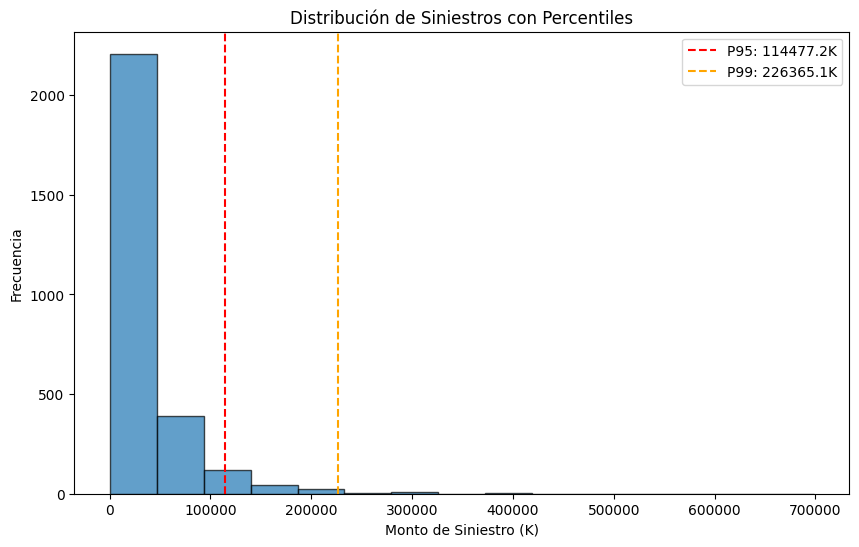

outliers potenciales: 141
outliers extremos: 29


In [63]:
import numpy as np
import matplotlib.pyplot as plt

# Calcular percentiles
p25 = np.percentile(siniestros, 25)
p50 = np.percentile(siniestros, 50)
p75 = np.percentile(siniestros, 75)
p90 = np.percentile(siniestros, 90)
p95 = np.percentile(siniestros, 95)
p99 = np.percentile(siniestros, 99)

print(f"P25: {p25}")
print(f"P50 (Mediana): {p50}")
print(f"P75: {p75}")
print(f"P90: {p90}")
print(f"P95: {p95}")
print(f"P99: {p99}")

# Visualizar con histograma
plt.figure(figsize=(10, 6))
plt.hist(siniestros, bins=15, edgecolor='black', alpha=0.7)
plt.axvline(p95, color='red', linestyle='--', label=f'P95: {p95:.1f}K')
plt.axvline(p99, color='orange', linestyle='--', label=f'P99: {p99:.1f}K')
plt.xlabel('Monto de Siniestro (K)')
plt.ylabel('Frecuencia')
plt.legend()
plt.title('Distribución de Siniestros con Percentiles')
plt.show()

print(f"outliers potenciales: {len(datos_GMM[datos_GMM['monto_pagado'] > p95])}")
print(f"outliers extremos: {len(datos_GMM[datos_GMM['monto_pagado'] > p99])}")


In [64]:
# fig = px.box(
#     datos_GMM, x='g_edad', y='monto_pagado',
#     notched=True,   # la muesca = intervalo de confianza de la mediana
#     title='Distribución por grupo de edad',
#     labels={'prima_total':'Prima (MXN)'},
# )
# fig.update_layout(showlegend=False, height=430)
# fig.show()

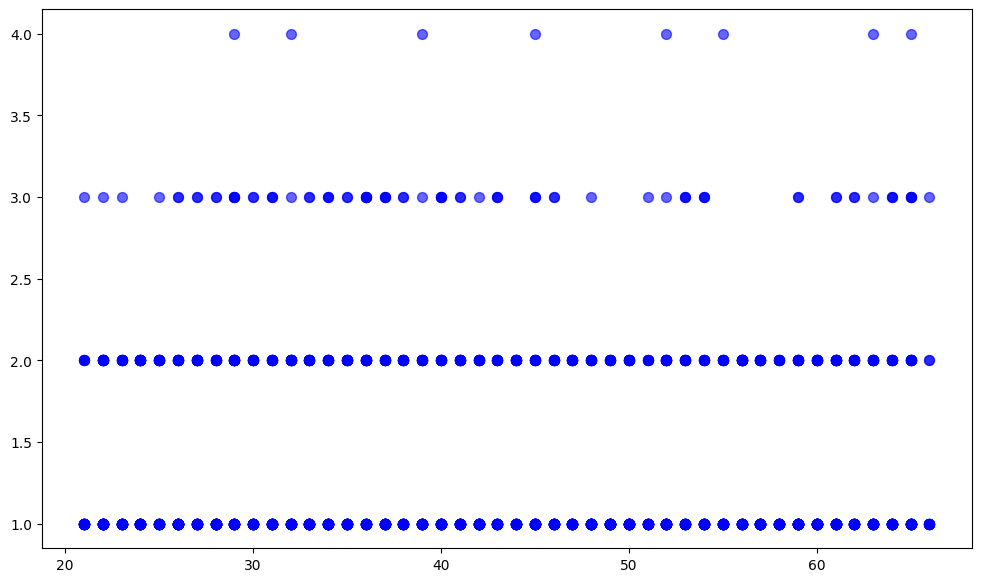

In [75]:
fig, ax = plt.subplots(figsize=(12, 7))


ax.scatter(datos_GMM['edad'], datos_GMM['n_siniestros'], 
          alpha=0.6, label='Normal', s=50, color='blue')

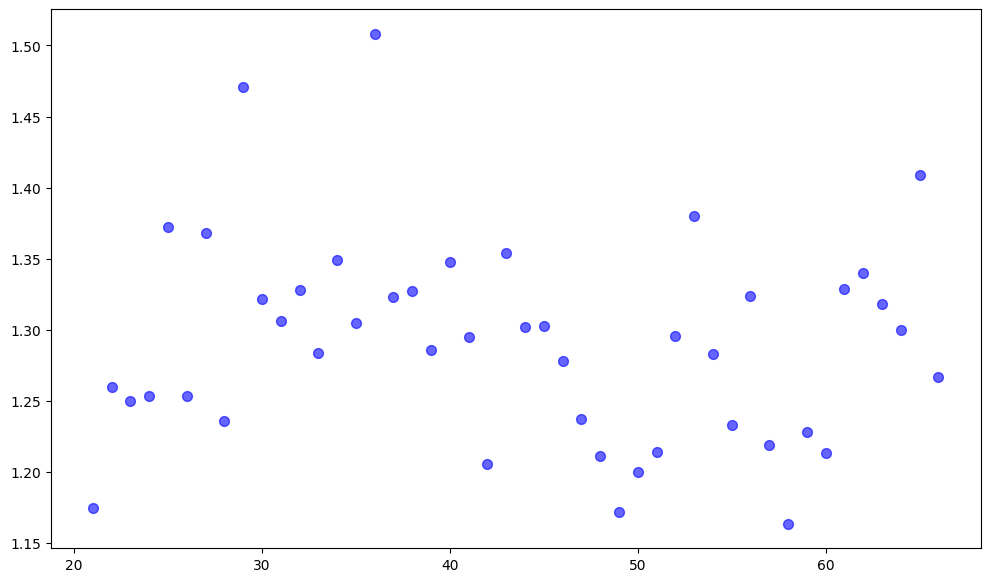

In [79]:
resumen_gmm = datos_GMM.groupby('edad').agg(
    polizas = ('id_poliza', 'count'),
    siniestros = ('n_siniestros','sum')
).reset_index()
resumen_gmm['Frecuencia'] = resumen_gmm['siniestros']/resumen_gmm['polizas']

fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(resumen_gmm['edad'], resumen_gmm['Frecuencia'], 
          alpha=0.6, label='Normal', s=50, color='blue')



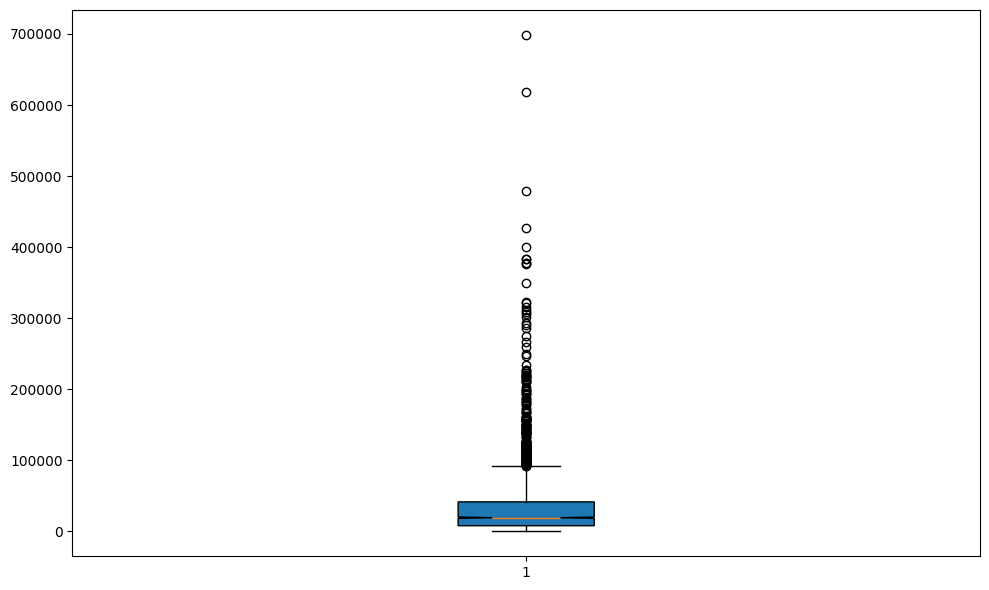

In [65]:
# Crear boxplot
from mi_modulo import grupo_edad



fig, ax = plt.subplots(figsize=(10, 6))


bp = ax.boxplot([datos_GMM['monto_pagado']],
                 notch=True,           # Añade muescas
                 patch_artist=True)    # Permite colorear

plt.tight_layout()
plt.show()

In [67]:

p95 = np.percentile(datos_GMM['monto_pagado'], 95)
p99 = np.percentile(datos_GMM['monto_pagado'], 99)

print('ANTES DE LIMPIEZA:')
print(f"Media: ${datos_GMM['monto_pagado'].mean():.2f}")
print(f"Mediana: ${datos_GMM['monto_pagado'].median():.2f}")

# Verificar datos erroneos y outliers
filtro_positivos = datos_GMM['monto_pagado'] > 0
filtro_outliers = datos_GMM['monto_pagado'] >= p95
filtro_ambos = (datos_GMM['monto_pagado'] > 0) & (datos_GMM['monto_pagado'] < p95)

datos_limpios1 = datos_GMM.loc[filtro_outliers].copy()
datos_limpios2 = datos_GMM.loc[filtro_positivos].copy()
datos_limpios3 = datos_GMM.loc[filtro_ambos].copy()

print('DESPUÉS DE LIMPIEZA:')
print(f"Datos originales: {len(datos_GMM)}")
print(f"Después quitar outliers: {len(datos_limpios1)} (eliminados: {len(datos_GMM) - len(datos_limpios1)})")
print(f"Después quitar negativos: {len(datos_limpios2)} (eliminados: {len(datos_GMM) - len(datos_limpios2)})")
print(f"Después ambos criterios: {len(datos_limpios3)} (eliminados: {len(datos_GMM) - len(datos_limpios3)})")
print(f"Media original: ${datos_GMM['monto_pagado'].mean():.2f}")
print(f"Media limpia: ${datos_limpios3['monto_pagado'].mean():.2f}")
print(f"Diferencia: {(datos_GMM['monto_pagado'].mean() - datos_limpios3['monto_pagado'].mean()) / datos_GMM['monto_pagado'].mean() * 100:.1f}%")

ANTES DE LIMPIEZA:
Media: $34451.58
Mediana: $19381.15
DESPUÉS DE LIMPIEZA:
Datos originales: 2813
Después quitar outliers: 141 (eliminados: 2672)
Después quitar negativos: 2813 (eliminados: 0)
Después ambos criterios: 2672 (eliminados: 141)
Media original: $34451.58
Media limpia: $26033.49
Diferencia: 24.4%


In [73]:
def winsorizar(datos, percentil_bajo=5, percentil_alto=95):
    limite_bajo = np.percentile(datos, percentil_bajo)
    limite_alto = np.percentile(datos, percentil_alto)
    datos_winsorizado = np.clip(datos, limite_bajo, limite_alto)
    return {
        'original': datos,
        'winsorizado': datos_winsorizado,
        'limite_bajo': limite_bajo,
        'limite_alto': limite_alto
    }

resultado = winsorizar(datos_GMM["monto_pagado"], percentil_bajo=5, percentil_alto=95)

print('=== COMPARACIÓN: ORIGINAL vs WINSORIZADO ===')
print()
print(f"Límite inferior (P5): ${resultado['limite_bajo']:,.2f}")
print(f"Límite superior (P95): ${resultado['limite_alto']:,.2f}")
print(f"{'Estadística':<20} {'Original':<15} {'Winsorizado':<15} {'Cambio %':<10}")
print('-' * 60)

media_orig = np.mean(resultado['original'])
media_wins = np.mean(resultado['winsorizado'])
mediana_orig = np.median(resultado['original'])
mediana_wins = np.median(resultado['winsorizado'])
std_orig = np.std(resultado['original'])
std_wins = np.std(resultado['winsorizado'])
max_orig = np.max(resultado['original'])
max_wins = np.max(resultado['winsorizado'])

print(f"{'Media':<20} ${media_orig:>13,.2f} ${media_wins:>13,.2f} {(media_wins - media_orig) / media_orig * 100:>8.1f}%")
print(f"{'Mediana':<20} ${mediana_orig:>13,.2f} ${mediana_wins:>13,.2f} {(mediana_wins - mediana_orig) / mediana_orig * 100:>8.1f}%")
print(f"{'Desv. Estándar':<20} ${std_orig:>13,.2f} ${std_wins:>13,.2f} {(std_wins - std_orig) / std_orig * 100:>8.1f}%")
print(f"{'Máximo':<20} ${max_orig:>13,.2f} ${max_wins:>13,.2f} {(max_wins - max_orig) / max_orig * 100:>8.1f}%")
print()
print(f"{'Reserva Original':<20} ${media_orig * len(resultado['original']):>13,.2f}")
print(f"{'Reserva Winsorizada':<20} ${media_wins * len(resultado['winsorizado']):>13,.2f}")
print(f"{'Diferencia':<20} ${(media_orig - media_wins) * len(resultado['original']):>13,.2f}")

=== COMPARACIÓN: ORIGINAL vs WINSORIZADO ===

Límite inferior (P5): $1,614.20
Límite superior (P95): $114,477.22
Estadística          Original        Winsorizado     Cambio %  
------------------------------------------------------------
Media                $    34,451.58 $    30,505.11    -11.5%
Mediana              $    19,381.15 $    19,381.15      0.0%
Desv. Estándar       $    48,613.36 $    30,776.63    -36.7%
Máximo               $   698,744.32 $   114,477.22    -83.6%

Reserva Original     $96,912,286.07
Reserva Winsorizada  $85,810,885.11
Diferencia           $11,101,400.96


In [69]:
resultado_winsor_gmm = winsorizar(datos_GMM['monto_pagado'], percentil_bajo=5, percentil_alto=95)

print('=== COMPARACIÓN: ORIGINAL vs WINSORIZADO ===')
print()
print(f"Límite inferior (P5): ${resultado_winsor_gmm['limite_bajo']:,.2f}")
print(f"Límite superior (P95): ${resultado_winsor_gmm['limite_alto']:,.2f}")
print(f"{'Estadística':<20} {'Original':<15} {'Winsorizado':<15} {'Cambio %':<10}")
print('-' * 60)

media_orig = np.mean(resultado_winsor_gmm['original'])
media_wins = np.mean(resultado_winsor_gmm['winsorizado'])
mediana_orig = np.median(resultado_winsor_gmm['original'])
mediana_wins = np.median(resultado_winsor_gmm['winsorizado'])
std_orig = np.std(resultado_winsor_gmm['original'])
std_wins = np.std(resultado_winsor_gmm['winsorizado'])
max_orig = np.max(resultado_winsor_gmm['original'])
max_wins = np.max(resultado_winsor_gmm['winsorizado'])

print(f"{'Media':<20} ${media_orig:>13.2f} ${media_wins:>13,.2f} {(media_wins - media_orig) / media_orig * 100:>8,.1f}%")
print(f"{'Mediana':<20} ${mediana_orig:>13,.2f} ${mediana_wins:>13,.2f} {(mediana_wins - mediana_orig) / mediana_orig * 100:>8,.1f}%")
print(f"{'Desv. Estándar':<20} ${std_orig:>13.2f} ${std_wins:>13,.2f} {(std_wins - std_orig) / std_orig * 100:>8,.1f}%")
print(f"{'Máximo':<20} ${max_orig:>13,.2f} ${max_wins:>13,.2f} {(max_wins - max_orig) / max_orig * 100:>8,.1f}%")
print()
print(f"{'Reserva Original':<20} ${media_orig * len(resultado_winsor_gmm['original']):>13,.2f}")
print(f"{'Reserva Winsorizada':<20} ${media_wins * len(resultado_winsor_gmm['winsorizado']):>13,.2f}")
print(f"{'Diferencia':<20} ${(media_orig - media_wins) * len(resultado_winsor_gmm['original']):>13,.2f}")

=== COMPARACIÓN: ORIGINAL vs WINSORIZADO ===

Límite inferior (P5): $1,614.20
Límite superior (P95): $114,477.22
Estadística          Original        Winsorizado     Cambio %  
------------------------------------------------------------
Media                $     34451.58 $    30,505.11    -11.5%
Mediana              $    19,381.15 $    19,381.15      0.0%
Desv. Estándar       $     48613.36 $    30,776.63    -36.7%
Máximo               $   698,744.32 $   114,477.22    -83.6%

Reserva Original     $96,912,286.07
Reserva Winsorizada  $85,810,885.11
Diferencia           $11,101,400.96
